In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


In [2]:
import warnings
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score,cross_validate
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler,LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score

**importing data set**

In [3]:
df_=pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
df=df_.copy()

**Separating variables by type**

In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    It gives the names of categorical, numerical and categorical but cardinal variables in the data set.
    Note: Categorical variables with numerical appearance are also included in categorical variables.

    Parameters
    ------
        dataframe: dataframe
                The dataframe from which variable names are to be retrieved
        cat_th: int, optional
                Class threshold value for numeric but categorical variables
        car_th: int, optinal
                Class threshold for categorical but cardinal variables

    Returns
    ------
        cat_cols: list
                Categorical variable list
        num_cols: list
                Numerical variable list
        cat_but_car: list
                Categorical view cardinal variable list

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = the total number of variables
        num_but_cat is inside cat_cols.
        The sum of 3 lists with return is equal to the total number of variables: cat_cols + num_cols + cat_but_car = number of variables

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car

In [5]:
cat_cols, num_cols, cat_but_car =grab_col_names(df)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


**Examination of categoric columns**

In [6]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()



In [7]:
for col in cat_cols:
    cat_summary(df, col)

   Outcome      Ratio
0      500  65.104167
1      268  34.895833


**Examination of categoric columns**

In [8]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=50)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

    print("#####################################")

In [9]:
for col in num_cols:
    num_summary(df, col)

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
5%         0.000000
10%        0.000000
20%        1.000000
30%        1.000000
40%        2.000000
50%        3.000000
60%        4.000000
70%        5.000000
80%        7.000000
90%        9.000000
95%       10.000000
99%       13.000000
max       17.000000
Name: Pregnancies, dtype: float64
#####################################
count    768.000000
mean     120.894531
std       31.972618
min        0.000000
5%        79.000000
10%       85.000000
20%       95.000000
30%      102.000000
40%      109.000000
50%      117.000000
60%      125.000000
70%      134.000000
80%      147.000000
90%      167.000000
95%      181.000000
99%      196.000000
max      199.000000
Name: Glucose, dtype: float64
#####################################
count    768.000000
mean      69.105469
std       19.355807
min        0.000000
5%        38.700000
10%       54.000000
20%       60.000000
30%       64.000000
40%       68.000000


**Examining numeric columns by target variable**

In [10]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

In [11]:
for col in cat_cols:
    target_summary_with_cat(df,"Outcome",col)


         TARGET_MEAN
Outcome             
0                0.0
1                1.0




**Examining the correlation**

In [12]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.70):
    corr = dataframe.corr()
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(np.bool))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={'figure.figsize': (15, 15)})
        sns.heatmap(corr, cmap="RdBu")
        plt.show()
    return drop_list

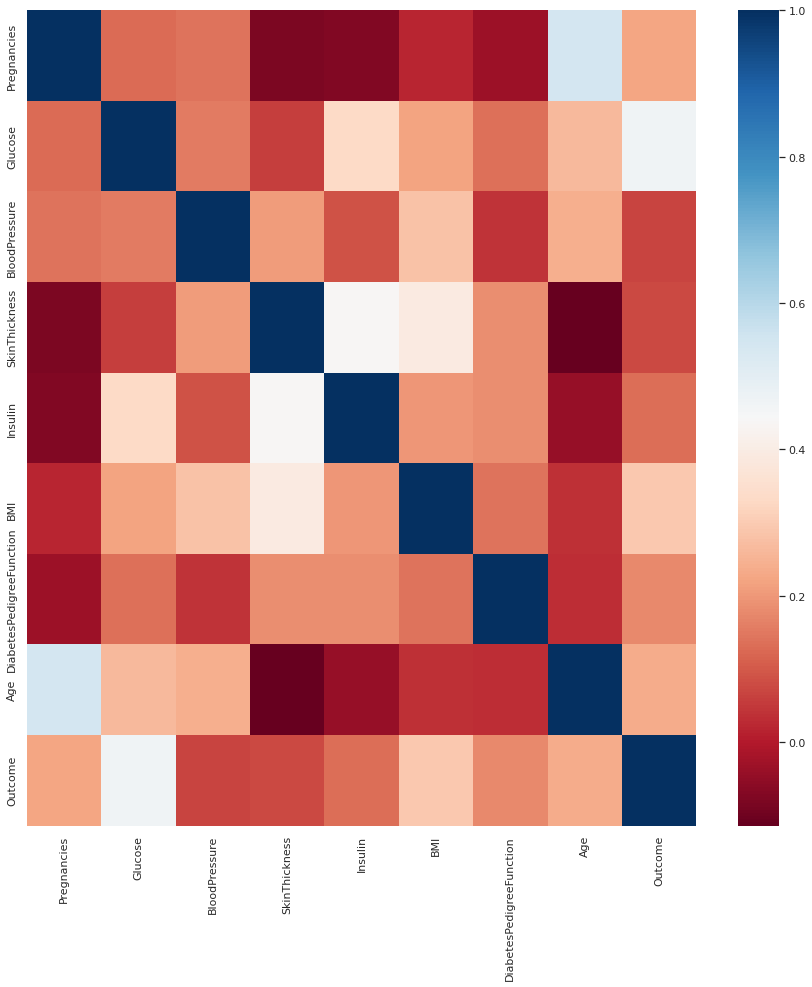

[]

In [13]:
high_correlated_cols(df, plot=True)

**Outlier detection**

In [14]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [15]:
for i in df.columns:
    low, up =outlier_thresholds(df, i)
    if ((df[i] < low) | (df[i] > up)).any():
        print(f"\nIndices: {df[(df[i] < low) | (df[i] > up)].index}\n")
        print(df[(df[i] < low) | (df[i] > up)].head())
        replace_with_thresholds(df,i)


Indices: Int64Index([13, 228], dtype='int64')

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
13             1      189             60             23      846  30.1   
228            4      197             70             39      744  36.7   

     DiabetesPedigreeFunction  Age  Outcome  
13                      0.398   59        1  
228                     2.329   31        0  


**Observing missing values**

In [16]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

In [17]:
na_cols=missing_values_table(df, True)

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


**Filling missing values with "Null"**

In [18]:
def apply_values_with_null(df, column):
    df[column] = df[column].apply(lambda x: np.nan if x == 0 else x)

In [19]:
columns=["Insulin","BMI","Glucose","SkinThickness","DiabetesPedigreeFunction"]
for column in columns:
    apply_values_with_null(df,column)

In [20]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


**create dummy variables**

In [21]:
dff = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)

**Standardization of variables**

In [22]:
scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(dff), columns=dff.columns)
df.head()

,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.0,0.352941,0.670968,0.590164,0.304348,NaN,0.314928,0.234415,0.483333
1,0.0,0.058824,0.264516,0.540984,0.239130,NaN,0.171779,0.116567,0.166667
2,1.0,0.470588,0.896774,0.524590,NaN,NaN,0.104294,0.253629,0.183333
3,0.0,0.058824,0.290323,0.540984,0.173913,0.111343,0.202454,0.038002,0.000000
4,1.0,0.000000,0.600000,0.327869,0.304348,0.214335,0.509202,0.943638,0.200000


**Application of the KNN**

In [23]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df.head()
df = pd.DataFrame(scaler.inverse_transform(df), columns=df.columns)

In [24]:
df["Pregnancies_Glucose"]=df["Pregnancies"]*df["Glucose"]
df["Glucose/Insulin"]=df["Glucose"]/df["Insulin"]
df["BloodPressure/Age"]=df["BloodPressure"]/df["Age"]
df["DiabetesPedigreeFunction/Age"]=df["DiabetesPedigreeFunction"]/df["Age"]
df["DiabetesPedigreeFunction/BloodPressure"]=df["DiabetesPedigreeFunction"]*df["BloodPressure"]
df["Age_Glucose"]=df["Age"]*df["Glucose"]
df["BloodPressure*SkinThickness"]=df["SkinThickness"]*df["BloodPressure"]
df["Glucose*Insulin"]=df["Glucose"]*df["Insulin"]
df["DiabetesPedigreeFunction/Insulin"]=df["DiabetesPedigreeFunction"]/df["Insulin"]

df.loc[(df["Glucose"] < 70) & ((df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "lowmature"
df.loc[(df["Glucose"] < 70) & (df["Age"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "lowsenior"
df.loc[((df["Glucose"] >= 70) & (df["Glucose"] < 100)) & (
            (df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "normalmature"
df.loc[((df["Glucose"] >= 70) & (df["Glucose"] < 100)) & (df["Age"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "normalsenior"
df.loc[((df["Glucose"] >= 100) & (df["Glucose"] <= 125)) & (
            (df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "hiddenmature"
df.loc[((df["Glucose"] >= 100) & (df["Glucose"] <= 125)) & (df["Age"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "hiddensenior"
df.loc[(df["Glucose"] > 125) & ((df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "highmature"
df.loc[(df["Glucose"] > 125) & (df["Age"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "highsenior"

df.loc[(df["BMI"] < 18.5) & ((df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_BMI_NOM"] = "underweightmature"
df.loc[(df["BMI"] < 18.5) & (df["Age"] >= 50), "NEW_AGE_BMI_NOM"] = "underweightsenior"
df.loc[((df["BMI"] >= 18.5) & (df["BMI"] < 25)) & (
            (df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_BMI_NOM"] = "healthymature"
df.loc[((df["BMI"] >= 18.5) & (df["BMI"] < 25)) & (df["Age"] >= 50), "NEW_AGE_BMI_NOM"] = "healthysenior"
df.loc[((df["BMI"] >= 25) & (df["BMI"] < 30)) & (
            (df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_BMI_NOM"] = "overweightmature"
df.loc[((df["BMI"] >= 25) & (df["BMI"] < 30)) & (df["Age"] >= 50), "NEW_AGE_BMI_NOM"] = "overweightsenior"
df.loc[(df["BMI"] > 18.5) & ((df["Age"] >= 21) & (df["Age"] < 50)), "NEW_AGE_BMI_NOM"] = "obesemature"
df.loc[(df["BMI"] > 18.5) & (df["Age"] >= 50), "NEW_AGE_BMI_NOM"] = "obesesenior"

**Label Encoding**

In [25]:
def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [26]:
binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

for col in binary_cols:
    label_encoder(df, col)

**One Hot Encoding**

In [27]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe


In [28]:
ohe_cols = [col for col in df.columns if 10 >= df[col].nunique() > 2]
one_hot_encoder(df, ohe_cols).head()

,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Pregnancies_Glucose,...,DiabetesPedigreeFunction/Insulin,NEW_AGE_GLUCOSE_NOM_hiddensenior,NEW_AGE_GLUCOSE_NOM_highmature,NEW_AGE_GLUCOSE_NOM_highsenior,NEW_AGE_GLUCOSE_NOM_lowmature,NEW_AGE_GLUCOSE_NOM_lowsenior,NEW_AGE_GLUCOSE_NOM_normalmature,NEW_AGE_GLUCOSE_NOM_normalsenior,NEW_AGE_BMI_NOM_obesesenior,NEW_AGE_BMI_NOM_underweightmature
0,1.0,6.0,148.0,72.0,35.0,334.2,33.6,0.627,50.0,888.0,...,0.001876,0,0,1,0,0,0,0,1,0
1,0.0,1.0,85.0,66.0,29.0,56.2,26.6,0.351,31.0,85.0,...,0.006246,0,0,0,0,0,1,0,0,0
2,1.0,8.0,183.0,64.0,32.2,238.0,23.3,0.672,32.0,1464.0,...,0.002824,0,1,0,0,0,0,0,0,0
3,0.0,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,89.0,...,0.001777,0,0,0,0,0,1,0,0,0
4,1.0,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,0.0,...,0.013619,0,1,0,0,0,0,0,0,0


**Min-Max Scaling**

In [29]:
def MM_Scaler(dataframe,col):
    mm = MinMaxScaler()
    dataframe[f"{col}_scaler"] = mm.fit_transform(dataframe[[col]])

In [30]:
cat_cols, num_cols, cat_but_car =grab_col_names(df)
for column in num_cols:
    MM_Scaler(df,col)

Observations: 768
Variables: 20
cat_cols: 3
num_cols: 17
cat_but_car: 0
num_but_cat: 1


**Creating Dummy Variables**

In [31]:
df = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)

**RandomForestClassifier**

**Spliting data set with Hol-Out Method**

In [32]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

**Fitting the model**

In [33]:
RF_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)

**Predict test set****

In [34]:
y_pred = RF_model.predict(X_test)

**Calculating Accuracy score**

In [35]:
accuracy_score(y_pred, y_test)

0.8051948051948052

**Calculating mean squared errors**

In [36]:
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MSE: {round(mse, 4)} ({RF_model}) ")
print(f"RMSE: {round(rmse, 4)} ({RF_model}) ")

MSE: 0.1948 (RandomForestClassifier(random_state=46)) 
RMSE: 0.4414 (RandomForestClassifier(random_state=46)) 


**Calculating Accuracy Metrics**

In [37]:
print(f"Accuracy: {round(accuracy_score(y_pred, y_test), 2)}")
print(f"Recall: {round(recall_score(y_pred, y_test), 3)}")
print(f"Precision: {round(precision_score(y_pred, y_test), 2)}")
print(f"F1: {round(f1_score(y_pred, y_test), 2)}")
print(f"Auc: {round(roc_auc_score(y_pred, y_test), 2)}")

Accuracy: 0.81
Recall: 0.725
Precision: 0.72
F1: 0.72
Auc: 0.79


**If you have small data set you can use K Fold Cross Validation**

In [38]:
cv_results = cross_validate(RF_model,
                            X, y,
                            cv=5,
                            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

In [39]:
print(f"Accuracy: {round(cv_results['test_accuracy'].mean(), 3)}")
print(f"Recall: {round(cv_results['test_recall'].mean(), 3)}")
print(f"Precision: {round(cv_results['test_precision'].mean(), 3)}")
print(f"F1: {round(cv_results['test_f1'].mean(),3)}")
print(f"Auc: {round(cv_results['test_roc_auc'].mean(), 3)}")

Accuracy: 0.797
Recall: 0.687
Precision: 0.725
F1: 0.702
Auc: 0.868


In [40]:
y_predict=RF_model.predict(X)

**LinearRegression**

In [41]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)
y_prd= LR_model.predict(X_test)
mse = mean_squared_error(y_test, y_prd)
rmse=np.sqrt(mean_squared_error(y_test, y_prd))
print(f"MSE: {round(mse, 4)} ({RF_model}) ")
print(f"RMSE: {round(rmse, 4)} ({RF_model}) ")

MSE: 0.1575 (RandomForestClassifier(random_state=46)) 
RMSE: 0.3969 (RandomForestClassifier(random_state=46)) 


**10 Fold CV RMSE**

In [42]:
LR_model = LinearRegression()
rmse = np.mean(np.sqrt(-cross_val_score(LR_model, X, y, cv=10, scoring="neg_mean_squared_error")))
mse = mean_squared_error(y_test, y_prd)
print(f"RMSE: {round(rmse, 4)} ({LR_model}) ")
print(f"MSE: {round(mse, 4)} ({LR_model}) ")

RMSE: 0.3925 (LinearRegression()) 
MSE: 0.1575 (LinearRegression()) 


**LogisticRegression**

In [43]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)
LG_model= LogisticRegression(solver='liblinear')
LG_model.fit(X_train, y_train)
y_predi = LG_model.predict(X_test)
mse = mean_squared_error(y_test, y_predi)
rmse=np.sqrt(mean_squared_error(y_test, y_predi))
print(f"MSE: {round(mse, 4)} ({LG_model}) ")
print(f"RMSE: {round(rmse, 4)} ({LG_model}) ")


MSE: 0.2208 (LogisticRegression(solver='liblinear')) 
RMSE: 0.4699 (LogisticRegression(solver='liblinear')) 


In [44]:
print(f"Accuracy: {round(accuracy_score(y_predi, y_test), 2)}")
print(f"Recall: {round(recall_score(y_predi, y_test), 3)}")
print(f"Precision: {round(precision_score(y_predi, y_test), 2)}")
print(f"F1: {round(f1_score(y_predi, y_test), 2)}")
print(f"Auc: {round(roc_auc_score(y_predi, y_test), 2)}")

Accuracy: 0.78
Recall: 0.727
Precision: 0.59
F1: 0.65
Auc: 0.76


In [45]:
LGR_model = LogisticRegression(solver='liblinear')
rmse = np.mean(np.sqrt(-cross_val_score(LGR_model, X, y, cv=10, scoring="neg_mean_squared_error")))
mse = mean_squared_error(y_test, y_prd)
print(f"RMSE: {round(rmse, 4)} ({LGR_model}) ")
print(f"MSE: {round(mse, 4)} ({LGR_model}) ")

RMSE: 0.4694 (LogisticRegression(solver='liblinear')) 
MSE: 0.1575 (LogisticRegression(solver='liblinear')) 
